## Python For Machine Learning Fall 2025
---
# Transfer Learning

# 1. Introduction

The core idea of transfer learning—applying knowledge from one task (like pre-training on massive data) to a new task with less data (like fine-tuning)—has become a cornerstone of current AI development. The "Pre-training & Fine-tuning" paradigm is the most successful application of this concept.


## 1.1 Learning with Backgrounds

Imagine you've spent years learning to play the piano, mastering scales, chords, and music theory. If you then decide to learn the organ, you don't start from scratch. You **transfer** your existing knowledge of keys, reading music, and harmony to this new, but related, instrument.

In machine learning, Transfer Learning is this exact same idea.

**Transfer Learning** is a method where a model developed for one task is reused as the starting point for a model on a second, related task. We take the 'knowledge' a model has learned from one problem and apply it to a new, different problem.

## 1.2: Why is TL Indispensable?

This concept is critical for several reasons:

* **Data Scarcity** Training a SOTA model 'from scratch' requires an enormous amount of labeled data (e.g., millions of images). Most projects don't have this.
* **Computational Cost** Training massive models from scratch can take weeks or months on expensive GPU clusters, potentially costing a lot (millions of dollars for modern LLMs).
* **Better Performance:** A pre-trained model provides a much better starting point, often leading to higher accuracy and faster convergence, especially with limited data.

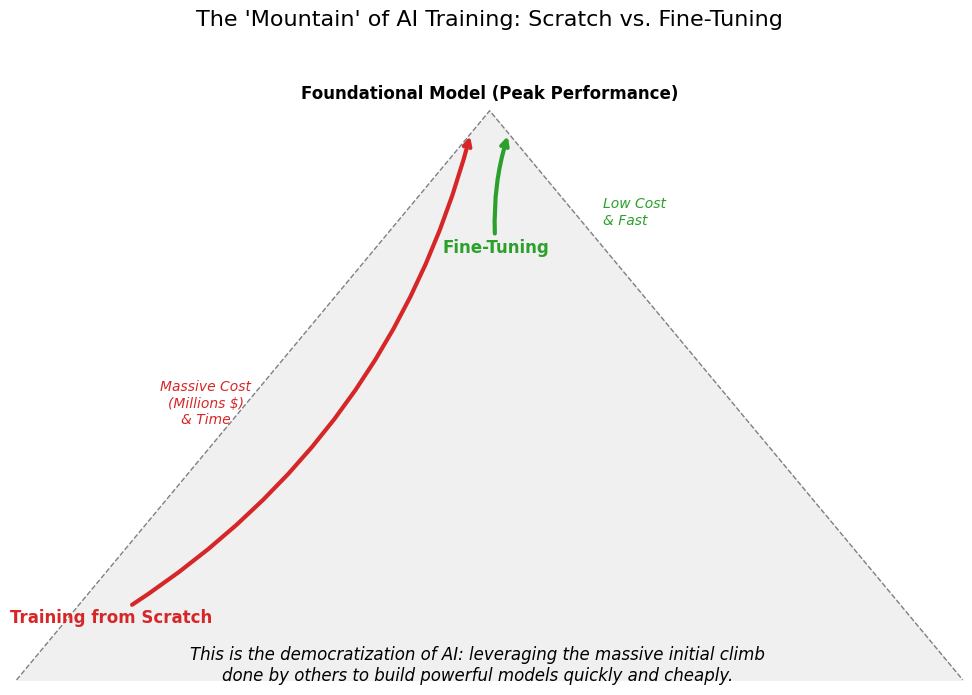

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot([0, 5, 10], [0, 10, 0], color='grey', linestyle='--', linewidth=1)
ax.fill_between([0, 5, 10], [0, 10, 0], color='#f0f0f0')
ax.text(5, 10.2, "Foundational Model (Peak Performance)", ha='center', fontsize=12, fontweight='bold')

ax.annotate(
    "Training from Scratch",
    xy=(4.8, 9.6),
    xytext=(1, 1),
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=0.2",
        linewidth=3.0,
        color="#d62728"
    ),
    fontsize=12,
    fontweight='bold',
    color="#d62728",
    ha='center'
)

ax.text(2, 4.5, "Massive Cost\n(Millions $)\n& Time",
        ha='center', fontsize=10, color="#d62728", style='italic')

ax.annotate(
    "Fine-Tuning",
    xy=(5.2, 9.6),
    xytext=(4.5, 7.5),
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=-0.1",
        linewidth=3.0,
        color="#2ca02c"
    ),
    fontsize=12,
    fontweight='bold',
    color="#2ca02c",
    ha='left'
)

ax.text(6.2, 8.0, "Low Cost\n& Fast",
        ha='left', fontsize=10, color="#2ca02c", style='italic')

ax.set_title("The 'Mountain' of AI Training: Scratch vs. Fine-Tuning", fontsize=16, pad=20)
fig.text(
    0.5,
    0.02, # Position at the bottom
    "This is the democratization of AI: leveraging the massive initial climb\n"
    "done by others to build powerful models quickly and cheaply.",
    ha='center',
    fontsize=12,
    style='italic'
)

ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.axis('off')

plt.tight_layout()
plt.show()

Reflection: Assume a global optimization exists, will TL reach the same performance as training from scratch?

# 2. Core Concepts & Techniques



## 2.1: Pre-trained Models

A pre-trained model is an AI model that has already been trained on a massive, general-purpose dataset by someone else. Think of it as a student who has already completed a vast, foundational education—like reading all of Wikipedia or analyzing millions of images. Because it has already learned the fundamental patterns, rules, and features of its domain (such as grammar and context for language, or edges, textures, and shapes for images), it doesn't need to start from scratch. Developers can then take this "smart" base model and quickly fine-tune it on a smaller, specific dataset for a new, specialized task, saving an enormous amount of time, data, and computational cost.


## 2.2: Fine-Tuning

Our specific problem usually isn't to classify 1,000 random things. We might want to classify 'Cat vs. Dog' or 'Tumor vs. Not-Tumor'.

This is where **fine-tuning** comes in. It's the process of taking the pre-trained model and **adapting** (or 'tuning') it on our own smaller, specific dataset.

#### Three Common Strategies:

1.  **Strategy 1: Feature Extractor**
    * We **freeze** all the original layers of the pre-trained model. It becomes a fixed 'black box' for feature extraction.
    * We chop off the original output layer and add a new classifier on the end (e.g., a 2-class 'Cat vs. Dog' layer).
    * We **only** train this new, small layer.
    * **Best for:** Small datasets that are very similar to the original.

2.  **Strategy 2: Fine-tuning a Few Top Layers (Most Common)**
    * We **freeze** the early layers (which learned universal features like edges/colors).
    * We **unfreeze** the later, more specialized layers.
    * We train both the unfrozen layers and our new classifier head. This is a great balance of speed and performance.

3.  **Strategy 3: End-to-End Fine-tuning**
    * We **unfreeze everything** and let the entire model train on our new data.
    * **CRITICAL:** We must use a **very, very small learning rate**. This prevents the model from 'forgetting' its valuable knowledge (known as 'catastrophic forgetting').
    * We just gently 'nudge' the weights to be better for our task.
    * **Best for:** When you have a fairly large dataset of your own.

## 2.3: Domain Adaptation

Transfer Learning has a key weakness: the **domain gap**.

- Source Domain (The "Big Data" Part): This is the massive, broad dataset used to create the initial pre-trained model. Think of this as the "general education" (e.g., all of Wikipedia, millions of public images). This is where a major company spends millions of dollars on a "big data" problem to teach the model the fundamentals of language, vision, or anor.

- Target Domain (The "Your Data" Part): This is your specific, often much smaller, dataset for your specific task. For example, you might only have 500 customer service emails or 1,000 images of your company's products.

**Your job is to ask: 'How similar is my data to the data this model was trained on?'**

# 3. The Scale of Deep Learning

Compared to today’s popular large models, the size and data requirements of Deep Convolutional Networks are no longer as staggering. Nevertheless, they remain massive and complex systems. Here, we will compute specific figures to demonstrate this.

## 3.1 ImageNet

ImageNet is a massive, publicly available dataset of over 14 million images that has been a driving force behind the modern revolution in artificial intelligence and deep learning.

| Feature | ImageNet-1K (ILSVRC Subset) | Full ImageNet (ImageNet-21K) |
| :--- | :--- | :--- |
| **Total Classes** | 1,000 | 21,841 |
| **Training Images** | ~1.28 million | ~14.2 million (total) |
| **Validation Images**| 50,000 | *No official split* |
| **Test Images** | 100,000 | *No official split* |
| **Total Images** | ~1.43 million | ~14.2 million |
| **Approx. Storage Size** | ~150 GB | ~1.3 TB |

In [ ]:
from IPython.display import display, Image
display(Image(url="https://www.uktech.news/wp-content/uploads/2025/11/QEP_051125_PM-23.jpg"))

## 3.2 VGG Net

VGG (Visual Geometry Group) is a family of deep convolutional neural network (DCNN) architectures, with VGG16 and VGG19 being the most famous. Developed by the University of Oxford, VGG's groundbreaking contribution in 2014 was demonstrating that a significant increase in network depth—stacking many more layers than previous models—was the key to achieving top-tier performance. Its design is notable for its extreme simplicity and uniformity, as it almost exclusively uses very small 3x3 convolutional filters stacked one after another. While this uniform depth made VGG highly effective and influential, it also results in a model that is very large (many parameters) and computationally expensive compared to more modern, efficient architectures like ResNet or Inception.

In [ ]:
import torch
from torchvision import models

def count_trainable_parameters(model):
  # Sum the number of elements for every parameter that has requires_grad=True
  return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)

total_params = count_trainable_parameters(model)

print(f"Total Trainable Parameters: {total_params:,}")

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 245MB/s]


Total Trainable Parameters: 143,667,240


Now consider the size of famous models:

* **VGG16** (now considered simple): **138 million** parameters
* **BERT-Large** (language model): **340 million** parameters
* **GPT-3** (language model): **175 billion** parameters

This massive computational challenge is the entire reason TL is an essential part of the modern toolkit.

# 4. Solutions Working with Massive DCNNs

* **Solution 1: Transfer Learning**
    * This is the practical, smart choice for 99% of us.

* **Solution 2: Distributed Training**
    * **Data Parallelism:** The most common method. You put a full copy of the model on multiple (e.g., 8) GPUs. You split the *data* batch, and each GPU processes a piece. They then average their results.
    * **Model Parallelism:** Needed when the model itself is too big to fit on one GPU. You *slice the model* and put different layers on different machines, like an assembly line. This is incredibly complex.

# 5. TL Strategies

**Feature Extraction** In this method, you treat the pre-trained model as a fixed tool. You "freeze" all its layers so their learned weights cannot change, chop off the original final layer (e.g., the 1000-class ImageNet head), and add a new, trainable layer on top that matches your specific task (e.g., 2 classes for "cat vs. dog"). You then train only this small new layer on your data. This is very fast and works well when your dataset is small and very similar to the original data.

**Fine-tuning** This approach starts like feature extraction, but after training the new head, you "unfreeze" some of the top layers of the pre-trained model. You then continue training, allowing these unfrozen layers and your new head to be updated together, but using a very low learning rate. This gently nudges the model's high-level learned features (like "shapes" or "patterns") to better fit the specific details of your new dataset, without destroying the valuable, general-purpose knowledge they already contain. This usually results in higher accuracy than feature extraction alone.

# 6. TL Example

Now, let's play with some code.

First, load a model from torchvision.models. We'll use ResNet-50, as it's a very common and effective baseline.

In [ ]:
from torchvision import datasets, models, transforms

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


For feature extraction, you must stop PyTorch from calculating gradients for the pre-trained weights. This "freezes" them, so they won't be updated during training.

In [ ]:
for param in model.parameters():
    param.requires_grad = False

The pre-trained model was trained on ImageNet (1,000 classes). You need to replace its final layer with a new one that matches the number of classes in your target domain (e.g., 10 classes for a "cat vs. dog vs. horse..." classifier).

In [ ]:
import torch.nn as nn

num_features = model.fc.in_features
num_classes = 10
model.fc = nn.Linear(num_features, num_classes)

We will use CIFAR10 as our example. Let's include the proprocessing from the ResNet50 Training.

In [ ]:
weights = models.ResNet50_Weights.DEFAULT
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Download and load CIFAR10 Dataset.

In [ ]:
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=preprocess
)

val_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=preprocess
)
print("Dataset loaded.")

100%|██████████| 170M/170M [00:14<00:00, 12.1MB/s]


Dataset loaded.


Create the dataloaders.

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

images, labels = next(iter(train_loader))
print(f"Shape of one image batch: {images.shape}")
print(f"Shape of one label batch: {labels.shape}")

Shape of one image batch: torch.Size([32, 3, 224, 224])
Shape of one label batch: torch.Size([32])


Train the model.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [ ]:
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

Epoch 1/5, Loss: 1.3332
Epoch 2/5, Loss: 0.7284
Epoch 3/5, Loss: 0.6677
Epoch 4/5, Loss: 0.4774
Epoch 5/5, Loss: 0.8945


#7. Summary

- **Transfer Learning is an essential skill.** It lets us build powerful models with less data and less compute.
- Its success **critically depends on the domain gap.** Always ask how similar your source and target data are.
- **Fine-tuning is a craft.** You must be smart about *what* you freeze and *what* learning rate you use.
- **This is practical and accessible.** The tools today put this state-of-the-art power within reach for all of us.